In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("dados/populacao.xlsx", sheet_name="Municípios", header=2)

df = df.dropna(subset=["COD. MUNIC"]).copy()

df.head()

,Unnamed: 0,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,NaN,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,NaN,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,NaN,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,NaN,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,NaN,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0


In [4]:

col_2010 = "População 2010 (Alterações de Limites até 2022)1" 
col_2022 = "População Censo 2022"

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 8 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Unnamed: 0                                        0 non-null      float64
 1   UF                                                5570 non-null   str    
 2   COD. UF                                           5570 non-null   float64
 3   COD. MUNIC                                        5570 non-null   float64
 4   NOME DO MUNICÍPIO                                 5570 non-null   str    
 5   População Município 2010
(Sinopse)                5570 non-null   float64
 6   População 2010 (Alterações de Limites até 2022)1  5570 non-null   float64
 7   População Censo 2022                              5570 non-null   float64
dtypes: float64(6), str(2)
memory usage: 348.3 KB


In [5]:
pop_estado = (
    df.groupby(["COD. UF", "UF"], as_index=False)
      .agg(
          populacao_2010=(col_2010, "sum"),
          populacao_2022=(col_2022, "sum"),
      )
)

pop_estado.head()

,COD. UF,UF,populacao_2010,populacao_2022
0,11.0,RO,1562409.0,1581196.0
1,12.0,AC,733559.0,830018.0
2,13.0,AM,3483985.0,3941613.0
3,14.0,RR,450479.0,636707.0
4,15.0,PA,7581051.0,8120131.0


In [6]:
pop_estado["crescimento"] = pop_estado["populacao_2022"] - pop_estado["populacao_2010"]

pop_estado = pop_estado.sort_values("crescimento", ascending=False).reset_index(drop=True)

pop_estado.head(10)

,COD. UF,UF,populacao_2010,populacao_2022,crescimento
0,35.0,SP,41262199.0,44411238.0,3149039.0
1,42.0,SC,6248436.0,7610361.0,1361925.0
2,52.0,GO,6001789.0,7056495.0,1054706.0
3,41.0,PR,10444526.0,11444380.0,999854.0
4,31.0,MG,19597330.0,20539989.0,942659.0
5,51.0,MT,3035122.0,3658649.0,623527.0
6,15.0,PA,7581051.0,8120131.0,539080.0
7,13.0,AM,3483985.0,3941613.0,457628.0
8,23.0,CE,8451644.0,8794957.0,343313.0
9,32.0,ES,3514952.0,3833712.0,318760.0


In [7]:
pop_estado.to_csv("output/populacao_por_estado.csv", sep=";", index=False)

In [8]:
pop_municipio = df[["COD. UF", "UF", "COD. MUNIC", "NOME DO MUNICÍPIO", col_2010, col_2022]].copy()

pop_municipio = pop_municipio.rename(columns={
    col_2010: "populacao_2010",
    col_2022: "populacao_2022",
})

pop_municipio.head()

,COD. UF,UF,COD. MUNIC,NOME DO MUNICÍPIO,populacao_2010,populacao_2022
0,11.0,RO,15.0,Alta Floresta D'Oeste,24392.0,21494.0
1,11.0,RO,23.0,Ariquemes,90353.0,96833.0
2,11.0,RO,31.0,Cabixi,6313.0,5351.0
3,11.0,RO,49.0,Cacoal,78574.0,86887.0
4,11.0,RO,56.0,Cerejeiras,17029.0,15890.0


In [9]:
pop_municipio["crescimento"] = pop_municipio["populacao_2022"] - pop_municipio["populacao_2010"]

pop_municipio = pop_municipio.sort_values("crescimento", ascending=False).reset_index(drop=True)

pop_municipio.head(10)

,COD. UF,UF,COD. MUNIC,NOME DO MUNICÍPIO,populacao_2010,populacao_2022,crescimento
0,13.0,AM,2603.0,Manaus,1802014.0,2063689.0,261675.0
1,53.0,DF,108.0,Brasília,2572159.0,2817381.0,245222.0
2,35.0,SP,50308.0,São Paulo,11253503.0,11451999.0,198496.0
3,35.0,SP,52205.0,Sorocaba,586816.0,723682.0,136866.0
4,52.0,GO,8707.0,Goiânia,1301912.0,1437366.0,135454.0
5,14.0,RR,100.0,Boa Vista,284313.0,413486.0,129173.0
6,42.0,SC,5407.0,Florianópolis,421240.0,537211.0,115971.0
7,15.0,PA,5536.0,Parauapebas,153908.0,267836.0,113928.0
8,50.0,MS,2704.0,Campo Grande,786774.0,898100.0,111326.0
9,25.0,PB,7507.0,João Pessoa,723515.0,833932.0,110417.0


In [10]:
pop_municipio.to_csv("output/populacao_por_municipio.csv", sep=";", index=False)

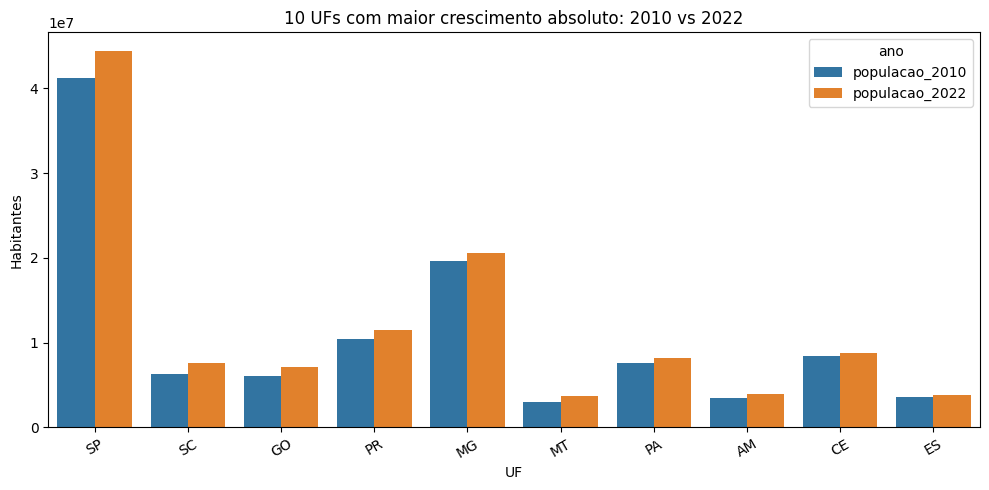

In [11]:

top = pop_estado.head(10).melt(
    id_vars="UF",
    value_vars=["populacao_2010", "populacao_2022"],
    var_name="ano",
    value_name="populacao",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="UF", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

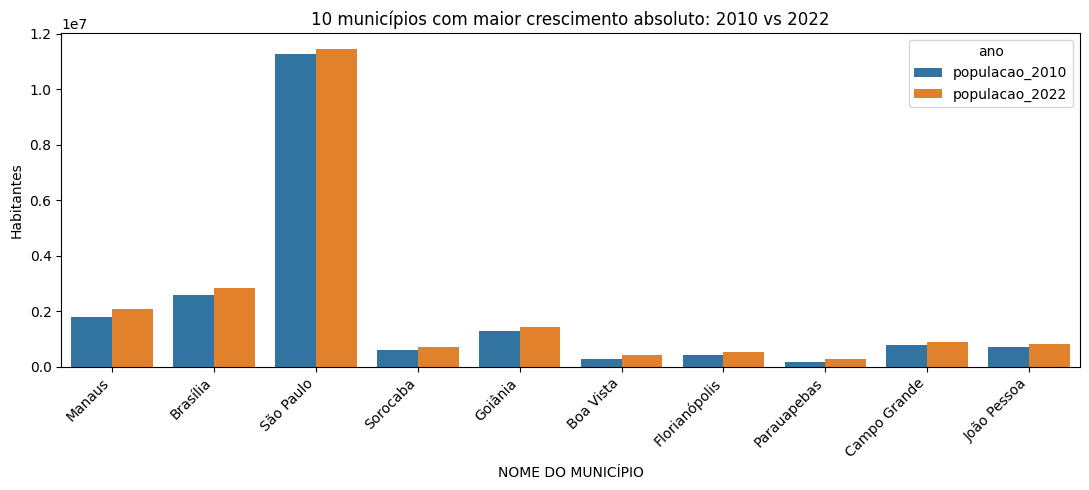

In [12]:
top_mun = pop_municipio.head(10).melt(
    id_vars="NOME DO MUNICÍPIO",
    value_vars=["populacao_2010", "populacao_2022"],
    var_name="ano",
    value_name="populacao",
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=top_mun, x="NOME DO MUNICÍPIO", y="populacao", hue="ano", ax=ax)
ax.set_title("10 municípios com maior crescimento absoluto: 2010 vs 2022")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()